In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import requests


#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import time
from datetime import date

# for graphs
import matplotlib.pyplot as plt

# Question 1: [IPO] Withdrawn IPOs by Company Type

In [2]:
import pandas as pd

url = "https://stockanalysis.com/ipos/withdrawn/"


headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/58.0.3029.110 Safari/537.3'
    )
}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(response.text)

/tmp/ipykernel_116837/2888363439.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [3]:
tables

[   Symbol                Company Name      Price Range Shares Offered
 0    ODTX  Odyssey Therapeutics, Inc.                -              -
 1    UNFL      Unifoil Holdings, Inc.    $3.00 - $4.00        2000000
 2    AURN        Aurion Biotech, Inc.                -              -
 3    ROTR             PHI Group, Inc.                -              -
 4     ONE           One Power Company                -              -
 ..    ...                         ...              ...            ...
 95    FHP   Freehold Properties, Inc.                -              -
 96    CHO                Chobani Inc.                -              -
 97   IFIT  iFIT Health & Fitness Inc.  $18.00 - $21.00       30769231
 98   GLGX  Gerson Lehrman Group, Inc.                -              -
 99    HCG               hear.com N.V.  $17.00 - $20.00       16220000
 
 [100 rows x 4 columns],
      Date Symbol                 Name
 0  Jun 24   FMFC     Kandal M Venture
 1  Jun 24   HCHL  Happy City Holdings
 2  

In [4]:
tables[0]

,Symbol,Company Name,Price Range,Shares Offered
0,ODTX,"Odyssey Therapeutics, Inc.",-,-
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000
2,AURN,"Aurion Biotech, Inc.",-,-
3,ROTR,"PHI Group, Inc.",-,-
4,ONE,One Power Company,-,-
...,...,...,...,...
95,FHP,"Freehold Properties, Inc.",-,-
96,CHO,Chobani Inc.,-,-
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231
98,GLGX,"Gerson Lehrman Group, Inc.",-,-


In [5]:
withdrawn = tables[0]

In [6]:
type(withdrawn)

pandas.core.frame.DataFrame

In [7]:
withdrawn.dtypes

Symbol            object
Company Name      object
Price Range       object
Shares Offered    object
dtype: object

In [8]:
withdrawn.head()

,Symbol,Company Name,Price Range,Shares Offered
0,ODTX,"Odyssey Therapeutics, Inc.",-,-
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000
2,AURN,"Aurion Biotech, Inc.",-,-
3,ROTR,"PHI Group, Inc.",-,-
4,ONE,One Power Company,-,-


In [9]:
withdrawn.tail()

,Symbol,Company Name,Price Range,Shares Offered
95,FHP,"Freehold Properties, Inc.",-,-
96,CHO,Chobani Inc.,-,-
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231
98,GLGX,"Gerson Lehrman Group, Inc.",-,-
99,HCG,hear.com N.V.,$17.00 - $20.00,16220000


In [10]:
import re

def classify_company(name):
    # Eliminar comas, puntos y convertir en palabras
    words = re.findall(r'\b\w+\b', name.lower())  # sólo palabras, sin puntuación

    if "acquisition" in words and ("corp" in words or "corporation" in words):
        return "Acq.Corp"
    elif "inc" in words or "incorporated" in words:
        return "Inc"
    elif "group" in words:
        return "Group"
    elif "ltd" in words or "limited" in words:
        return "Limited"
    elif "holdings" in words:
        return "Holdings"
    else:
        return "Other"

withdrawn["Company Class"] = withdrawn["Company Name"].apply(classify_company)


In [11]:
withdrawn.head(10)

,Symbol,Company Name,Price Range,Shares Offered,Company Class
0,ODTX,"Odyssey Therapeutics, Inc.",-,-,Inc
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc
2,AURN,"Aurion Biotech, Inc.",-,-,Inc
3,ROTR,"PHI Group, Inc.",-,-,Inc
4,ONE,One Power Company,-,-,Other
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000,Limited
6,CABR,"Caring Brands, Inc.",$4.00,750000,Inc
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000,Inc
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000,Limited
9,KMCM,Key Mining Corp.,$2.25,4444444,Other


In [12]:
withdrawn["Company Class"].value_counts()

Company Class
Inc         51
Acq.Corp    21
Limited     17
Other        6
Group        4
Holdings     1
Name: count, dtype: int64

In [13]:
search_term = "oldings"
withdrawn[withdrawn["Company Name"].str.contains(search_term, case=False, na=False)]


,Symbol,Company Name,Price Range,Shares Offered,Company Class
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000,Limited
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000,Limited
27,AMGS,Prospect Energy Holdings Corp.,$10.00,7500000,Holdings
29,DRFY,Droneify Holdings Limited,$6.00 - $7.00,923077,Limited
35,VEG,Veg House Holdings Inc.,$5.00,1000000,Inc
58,JR,Jinrong Holdings Ltd.,$5.00,-,Limited
69,BTNC,Bridgetown 3 Holdings Limited,$10.00,20000000,Limited
80,DEFY,"Agora Digital Holdings, Inc.",-,-,Inc


In [14]:
withdrawn

,Symbol,Company Name,Price Range,Shares Offered,Company Class
0,ODTX,"Odyssey Therapeutics, Inc.",-,-,Inc
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc
2,AURN,"Aurion Biotech, Inc.",-,-,Inc
3,ROTR,"PHI Group, Inc.",-,-,Inc
4,ONE,One Power Company,-,-,Other
...,...,...,...,...,...
95,FHP,"Freehold Properties, Inc.",-,-,Inc
96,CHO,Chobani Inc.,-,-,Inc
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231,Inc
98,GLGX,"Gerson Lehrman Group, Inc.",-,-,Inc


In [15]:
def parse_avg_price(price_range):
    if isinstance(price_range, str):
        # Eliminar símbolos de dólar y espacios
        clean = price_range.replace("$", "").replace(" ", "")
        
        # Caso 1: rango de dos precios
        if "-" in clean:
            try:
                low, high = map(float, clean.split("-"))
                return round((low + high) / 2, 2)
            except:
                return None

        # Caso 2: precio único
        try:
            return float(clean)
        except:
            return None

    # Caso 3: valor nulo o guion
    return None

# Aplicar la función
withdrawn["Avg. Price"] = withdrawn["Price Range"].apply(parse_avg_price)


In [16]:
withdrawn.tail(10)

,Symbol,Company Name,Price Range,Shares Offered,Company Class,Avg. Price
90,DSTY,Dynasty Financial Partners Inc.,-,-,Inc,NaN
91,ALOHA,"Cariloha, Inc.",$9.00 - $11.00,2000000,Inc,10.0
92,DPAC,Deep Space Acquisition Corp. I,$10.00,21000000,Acq.Corp,10.0
93,GIF,"GigCapital6, Inc.",$10.00,20000000,Inc,10.0
94,HYIV,Haymaker Acquisition Corp. IV,$10.00,26100000,Acq.Corp,10.0
95,FHP,"Freehold Properties, Inc.",-,-,Inc,NaN
96,CHO,Chobani Inc.,-,-,Inc,NaN
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231,Inc,19.5
98,GLGX,"Gerson Lehrman Group, Inc.",-,-,Inc,NaN
99,HCG,hear.com N.V.,$17.00 - $20.00,16220000,Other,18.5


In [17]:
withdrawn.dtypes

Symbol             object
Company Name       object
Price Range        object
Shares Offered     object
Company Class      object
Avg. Price        float64
dtype: object

In [18]:
withdrawn["Shares Offered"].value_counts(dropna=False)

Shares Offered
-           28
20000000     9
7500000      4
2000000      3
3750000      3
1500000      2
2250000      2
1400000      2
10000000     2
30000000     2
15000000     2
25000000     2
18000000     2
1250000      2
3000000      2
750000       1
1200000      1
1333334      1
2106250      1
3500000      1
2500000      1
2775000      1
4444444      1
1095000      1
1000000      1
2300000      1
923077       1
1600000      1
2900000      1
500000       1
2625000      1
45000000     1
1300000      1
2651000      1
14500000     1
1150000      1
1333333      1
3726709      1
21687082     1
1270000      1
1350000      1
4190476      1
35000000     1
17500000     1
21000000     1
26100000     1
30769231     1
16220000     1
Name: count, dtype: int64

In [19]:
withdrawn.dtypes

Symbol             object
Company Name       object
Price Range        object
Shares Offered     object
Company Class      object
Avg. Price        float64
dtype: object

In [20]:
withdrawn["Shares Offered"] = pd.to_numeric(withdrawn["Shares Offered"], errors="coerce")

In [21]:
withdrawn.tail(10)

,Symbol,Company Name,Price Range,Shares Offered,Company Class,Avg. Price
90,DSTY,Dynasty Financial Partners Inc.,-,NaN,Inc,NaN
91,ALOHA,"Cariloha, Inc.",$9.00 - $11.00,2000000.0,Inc,10.0
92,DPAC,Deep Space Acquisition Corp. I,$10.00,21000000.0,Acq.Corp,10.0
93,GIF,"GigCapital6, Inc.",$10.00,20000000.0,Inc,10.0
94,HYIV,Haymaker Acquisition Corp. IV,$10.00,26100000.0,Acq.Corp,10.0
95,FHP,"Freehold Properties, Inc.",-,NaN,Inc,NaN
96,CHO,Chobani Inc.,-,NaN,Inc,NaN
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231.0,Inc,19.5
98,GLGX,"Gerson Lehrman Group, Inc.",-,NaN,Inc,NaN
99,HCG,hear.com N.V.,$17.00 - $20.00,16220000.0,Other,18.5


In [22]:
withdrawn["Withdrawn Value"] = withdrawn["Shares Offered"] * withdrawn["Avg. Price"]

In [23]:
withdrawn["Withdrawn Value"].notna().sum()

np.int64(71)

In [24]:
withdrawn

,Symbol,Company Name,Price Range,Shares Offered,Company Class,Avg. Price,Withdrawn Value
0,ODTX,"Odyssey Therapeutics, Inc.",-,NaN,Inc,NaN,NaN
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000.0,Inc,3.5,7000000.0
2,AURN,"Aurion Biotech, Inc.",-,NaN,Inc,NaN,NaN
3,ROTR,"PHI Group, Inc.",-,NaN,Inc,NaN,NaN
4,ONE,One Power Company,-,NaN,Other,NaN,NaN
...,...,...,...,...,...,...,...
95,FHP,"Freehold Properties, Inc.",-,NaN,Inc,NaN,NaN
96,CHO,Chobani Inc.,-,NaN,Inc,NaN,NaN
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231.0,Inc,19.5,600000004.5
98,GLGX,"Gerson Lehrman Group, Inc.",-,NaN,Inc,NaN,NaN


In [25]:
grouped = (
    withdrawn.groupby("Company Class")["Withdrawn Value"]
    .sum()
    .reset_index()
    .sort_values(by="Withdrawn Value", ascending=False)
)

print(grouped)


  Company Class  Withdrawn Value
0      Acq.Corp     4.021000e+09
3           Inc     2.257164e+09
5         Other     7.679200e+08
4       Limited     5.497346e+08
2      Holdings     7.500000e+07
1         Group     3.378750e+07


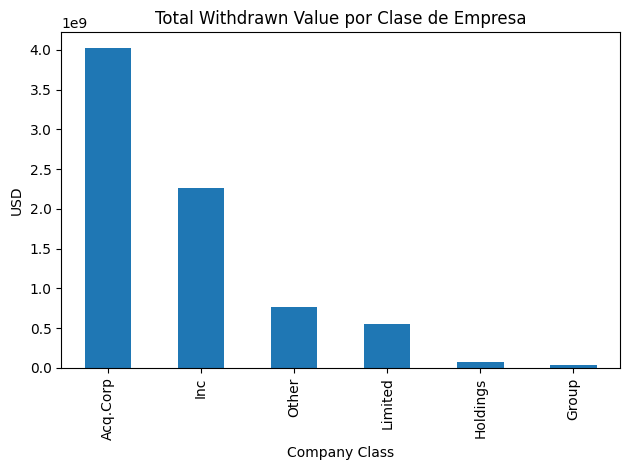

In [26]:
import matplotlib.pyplot as plt

grouped.plot(
    kind="bar",
    x="Company Class",
    y="Withdrawn Value",
    legend=False,
    title="Total Withdrawn Value por Clase de Empresa"
)
plt.ylabel("USD")
plt.tight_layout()
plt.show()


In [27]:
grouped_millions = (
    withdrawn.groupby("Company Class")["Withdrawn Value"]
    .sum()
    .div(1_000_000)  # <-- convierte a millones
    .reset_index(name="Withdrawn Value (M)")
    .sort_values(by="Withdrawn Value (M)", ascending=False)
)

print(grouped_millions)


  Company Class  Withdrawn Value (M)
0      Acq.Corp          4021.000000
3           Inc          2257.164205
5         Other           767.919999
4       Limited           549.734585
2      Holdings            75.000000
1         Group            33.787500


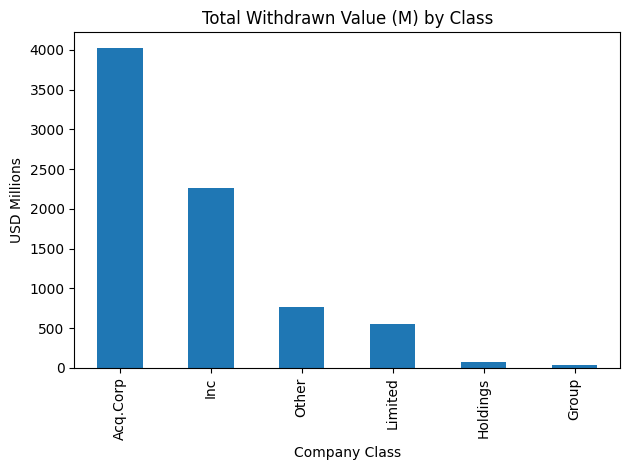

In [28]:
grouped_millions.plot(
    kind="bar",
    x="Company Class",
    y="Withdrawn Value (M)",
    legend=False,
    title="Total Withdrawn Value (M) by Class"
)
plt.ylabel("USD Millions")
plt.tight_layout()
plt.show()

# Question 2: [IPO] Median Sharpe Ratio for 2024 IPOs (First 5 Months)

In [29]:
import pandas as pd

url = "https://stockanalysis.com/ipos/2024/"


headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/58.0.3029.110 Safari/537.3'
    )
}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(response.text)

/tmp/ipykernel_116837/2700582724.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [30]:
tables[0]

,IPO Date,Symbol,Company Name,IPO Price,Current,Return
0,"Dec 31, 2024",ONEG,OneConstruction Group Limited,$4.00,$5.44,36.00%
1,"Dec 27, 2024",PHH,"Park Ha Biological Technology Co., Ltd.",$4.00,$30.11,652.75%
2,"Dec 23, 2024",HIT,"Health In Tech, Inc.",$4.00,$0.66,-83.45%
3,"Dec 23, 2024",TDAC,Translational Development Acquisition Corp.,$10.00,$10.27,2.70%
4,"Dec 20, 2024",RANG,Range Capital Acquisition Corp.,$10.00,$10.20,2.00%
...,...,...,...,...,...,...
220,"Jan 18, 2024",CCTG,CCSC Technology International Holdings Limited,$6.00,$1.07,-82.17%
221,"Jan 18, 2024",PSBD,Palmer Square Capital BDC Inc.,$16.45,$14.77,-10.21%
222,"Jan 12, 2024",SYNX,Silynxcom Ltd.,$4.00,$1.95,-51.25%
223,"Jan 11, 2024",SDHC,Smith Douglas Homes Corp.,$21.00,$18.40,-12.38%


In [31]:
ipos = tables[0] 

In [32]:
ipos.dtypes

IPO Date        object
Symbol          object
Company Name    object
IPO Price       object
Current         object
Return          object
dtype: object

In [33]:
ipos.columns = (
    ipos.columns
    .str.strip()         # quita espacios al inicio/final
    .str.lower()         # convierte a minúsculas
    .str.replace(" ", "_")  # reemplaza espacios por guiones bajos
)


In [34]:
ipos.dtypes

ipo_date        object
symbol          object
company_name    object
ipo_price       object
current         object
return          object
dtype: object

In [35]:
ipos["ipo_date"] = pd.to_datetime(ipos["ipo_date"], errors="coerce")

In [36]:
ipos_may = ipos[ipos["ipo_date"] < "2024-06-01"]
print(f"Total IPOs antes de junio 2024: {len(ipos_may)}")


Total IPOs antes de junio 2024: 77


In [37]:
ipos_may.sort_values('ipo_date').reset_index()

,index,ipo_date,symbol,company_name,ipo_price,current,return
0,224,2024-01-09,ROMA,Roma Green Finance Limited,$4.00,$2.85,-28.75%
1,223,2024-01-11,SDHC,Smith Douglas Homes Corp.,$21.00,$18.40,-12.38%
2,222,2024-01-12,SYNX,Silynxcom Ltd.,$4.00,$1.95,-51.25%
3,221,2024-01-18,PSBD,Palmer Square Capital BDC Inc.,$16.45,$14.77,-10.21%
4,220,2024-01-18,CCTG,CCSC Technology International Holdings Limited,$6.00,$1.07,-82.17%
...,...,...,...,...,...,...,...
72,152,2024-05-15,JDZG,JIADE Limited,$4.00,$0.26,-93.50%
73,151,2024-05-17,RFAI,RF Acquisition Corp II,$10.00,$10.59,5.90%
74,150,2024-05-17,HDL,Super Hi International Holding Ltd.,$19.56,$18.70,-4.40%
75,149,2024-05-23,BOW,Bowhead Specialty Holdings Inc.,$17.00,$37.25,119.12%


In [38]:
mask = (ipos_may["ipo_price"] == "-") | (ipos_may["current"] == "-")
incomplete = ipos_may[mask]
print(incomplete)


      ipo_date symbol                  company_name ipo_price current return
148 2024-05-31   NAKA               Kindly MD, Inc.         -  $16.30      -
174 2024-04-17   SUPX  SuperX AI Technology Limited         -   $9.94      -


In [39]:
filtered_ipos = ipos_may[~mask].copy()
filtered_ipos

,ipo_date,symbol,company_name,ipo_price,current,return
149,2024-05-23,BOW,Bowhead Specialty Holdings Inc.,$17.00,$37.25,119.12%
150,2024-05-17,HDL,Super Hi International Holding Ltd.,$19.56,$18.70,-4.40%
151,2024-05-17,RFAI,RF Acquisition Corp II,$10.00,$10.59,5.90%
152,2024-05-15,JDZG,JIADE Limited,$4.00,$0.26,-93.50%
153,2024-05-15,RAY,Raytech Holding Limited,$4.00,$1.18,-70.50%
...,...,...,...,...,...,...
220,2024-01-18,CCTG,CCSC Technology International Holdings Limited,$6.00,$1.07,-82.17%
221,2024-01-18,PSBD,Palmer Square Capital BDC Inc.,$16.45,$14.77,-10.21%
222,2024-01-12,SYNX,Silynxcom Ltd.,$4.00,$1.95,-51.25%
223,2024-01-11,SDHC,Smith Douglas Homes Corp.,$21.00,$18.40,-12.38%


* Download daily data OHLCV

In [40]:
ALL_TICKERS = filtered_ipos['symbol']
ALL_TICKERS

149     BOW
150     HDL
151    RFAI
152    JDZG
153     RAY
       ... 
220    CCTG
221    PSBD
222    SYNX
223    SDHC
224    ROMA
Name: symbol, Length: 75, dtype: object

In [41]:
import time

stocks_df = pd.DataFrame({'A' : []})

for i,ticker in enumerate(ALL_TICKERS):
  print(i,ticker)

  # Work with stock prices
  ticker_obj = yf.Ticker(ticker)

  # historyPrices = yf.download(tickers = ticker,
  #                    period = "max",
  #                    interval = "1d")
  historyPrices = ticker_obj.history(
                     period = "max",
                     interval = "1d")

  # generate features for historical prices, and what we want to predict
  historyPrices['Ticker'] = ticker
  historyPrices['Year']= historyPrices.index.year
  historyPrices['Month'] = historyPrices.index.month
  historyPrices['Weekday'] = historyPrices.index.weekday
  historyPrices['Date'] = historyPrices.index.date

  # historical returns
  for i in [1,3,7,30,90,252,365]:
    historyPrices['growth_'+str(i)+'d'] = historyPrices['Close'] / historyPrices['Close'].shift(i)
  historyPrices['growth_future_30d'] = historyPrices['Close'].shift(-30) / historyPrices['Close']

  # Technical indicators
  # SimpleMovingAverage 10 days and 20 days
  historyPrices['SMA10']= historyPrices['Close'].rolling(10).mean()
  historyPrices['SMA20']= historyPrices['Close'].rolling(20).mean()
  historyPrices['growing_moving_average'] = np.where(historyPrices['SMA10'] > historyPrices['SMA20'], 1, 0)
  historyPrices['high_minus_low_relative'] = (historyPrices.High - historyPrices.Low) / historyPrices['Close']

  # 30d rolling volatility : https://ycharts.com/glossary/terms/rolling_vol_30
  historyPrices['volatility'] =   historyPrices['Close'].rolling(30).std() * np.sqrt(252)

  # what we want to predict
  historyPrices['is_positive_growth_30d_future'] = np.where(historyPrices['growth_future_30d'] > 1, 1, 0)

  # sleep 1 sec between downloads - not to overload the API server
  time.sleep(1)


  if stocks_df.empty:
    stocks_df = historyPrices
  else:
    stocks_df = pd.concat([stocks_df, historyPrices], ignore_index=True)

0 BOW
1 HDL
2 RFAI
3 JDZG
4 RAY
5 BTOC
6 ZK
7 GPAT
8 PAL
9 SVCO
10 NNE
11 CCIX
12 VIK
13 ZONE
14 LOAR
15 MRX
16 RBRK
17 NCI
18 MFI
19 YYGH
20 TRSG
21 CDTG
22 CTRI
23 IBTA
24 MTEN
25 TWG
26 ULS
27 PACS
28 MNDR
29 CTNM
30 MAMO
31 ZBAO
32 BOLD
33 MMA
34 UBXG
35 IBAC
36 AUNA
37 BKHA
38 LOBO
39 RDDT
40 ALAB
41 INTJ
42 RYDE
43 LGCL
44 SMXT
45 VHAI
46 DYCQ
47 CHRO
48 UMAC
49 HLXB
50 MGX
51 TBBB
52 TELO
53 KYTX
54 PMNT
55 AHR
56 LEGT
57 ANRO
58 GUTS
59 AS
60 FBLG
61 AVBP
62 BTSG
63 HAO
64 CGON
65 YIBO
66 JL
67 SUGP
68 JVSA
69 KSPI
70 CCTG
71 PSBD
72 SYNX
73 SDHC
74 ROMA


In [42]:
stocks_df['Sharpe'] = (stocks_df['growth_252d'] - 0.045) / stocks_df['volatility']

In [43]:
stocks_df.dtypes

Open                             float64
High                             float64
Low                              float64
Close                            float64
Volume                             int64
Dividends                        float64
Stock Splits                     float64
Ticker                            object
Year                               int32
Month                              int32
Weekday                            int32
Date                              object
growth_1d                        float64
growth_3d                        float64
growth_7d                        float64
growth_30d                       float64
growth_90d                       float64
growth_252d                      float64
growth_365d                      float64
growth_future_30d                float64
SMA10                            float64
SMA20                            float64
growing_moving_average             int64
high_minus_low_relative          float64
volatility      

In [44]:
stocks_df["Date"] = pd.to_datetime(stocks_df["Date"], errors="coerce")

In [45]:
stocks_df_day = stocks_df[stocks_df["Date"] == "2025-06-06"]

In [46]:
stocks_df_day

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_252d,growth_365d,growth_future_30d,SMA10,SMA20,growing_moving_average,high_minus_low_relative,volatility,is_positive_growth_30d_future,Sharpe
259,36.439999,36.540001,35.930000,36.389999,137900,0.0,0.0,BOW,2025,6,...,1.442331,NaN,NaN,36.9540,37.70400,0,0.016763,24.508713,0,0.057014
533,20.430000,20.440001,19.969999,20.410000,1300,0.0,0.0,HDL,2025,6,...,1.007155,NaN,NaN,19.9660,21.08215,0,0.023028,18.816306,0,0.051134
775,10.510000,10.510000,10.510000,10.510000,0,0.0,0.0,RFAI,2025,6,...,NaN,NaN,NaN,10.4930,10.47935,1,0.000000,0.356043,0,NaN
1051,0.380000,0.386000,0.201000,0.295000,3428900,0.0,0.0,JDZG,2025,6,...,0.168571,NaN,NaN,0.4883,0.52880,0,0.627119,1.475159,0,0.083768
1327,1.110000,1.270000,1.100000,1.255000,501000,0.0,0.0,RAY,2025,6,...,0.343459,NaN,NaN,2.1015,1.90825,1,0.135458,9.314924,0,0.032041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21942,1.075000,1.100000,1.075000,1.095000,1600,0.0,0.0,CCTG,2025,6,...,0.500000,NaN,NaN,1.1434,1.18080,0,0.022831,1.297728,0,0.350613
22300,13.900000,14.000000,13.750000,13.880000,56200,0.0,0.0,PSBD,2025,6,...,0.947565,NaN,NaN,13.9030,13.74250,1,0.018012,9.712591,0,0.092927
22661,1.750000,1.750000,1.680000,1.680000,10000,0.0,0.0,SYNX,2025,6,...,0.626632,NaN,NaN,1.7435,1.82090,0,0.041667,1.368371,0,0.425054
23021,19.900000,20.150000,19.270000,19.270000,38100,0.0,0.0,SDHC,2025,6,...,0.758065,NaN,NaN,18.6850,18.66500,1,0.045667,16.442821,0,0.043366


In [47]:
stocks_df_day.growth_252d.describe()

count    71.000000
mean      1.152898
std       1.406017
min       0.024970
25%       0.293422
50%       0.758065
75%       1.362736
max       8.097413
Name: growth_252d, dtype: float64

In [48]:
filtro = stocks_df_day["growth_252d"].notna()
stocks_filtrados = stocks_df_day[filtro]

In [49]:
stocks_filtrados.shape

(71, 27)

In [50]:
stocks_df_day.Sharpe.describe()

count    71.000000
mean      0.288285
std       0.519028
min      -0.079677
25%       0.041215
50%       0.083768
75%       0.311507
max       2.835668
Name: Sharpe, dtype: float64

In [51]:
stocks_filtrados.Sharpe.describe()

count    71.000000
mean      0.288285
std       0.519028
min      -0.079677
25%       0.041215
50%       0.083768
75%       0.311507
max       2.835668
Name: Sharpe, dtype: float64

In [52]:
stocks_filtrados.sort_values('growth_252d',ascending= False).head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_252d,growth_365d,growth_future_30d,SMA10,SMA20,growing_moving_average,high_minus_low_relative,volatility,is_positive_growth_30d_future,Sharpe
20551,5.310000,5.355000,5.289000,5.320000,7700,0.0,0.0,JL,2025,6,...,8.097413,NaN,NaN,5.303000,4.734600,1,0.012406,14.221305,0,0.566222
23385,3.650000,3.950000,3.630000,3.700000,84400,0.0,0.0,ROMA,2025,6,...,6.156406,NaN,NaN,3.207100,2.625550,1,0.086486,12.553202,0,0.486840
14339,6.810000,8.650000,6.610000,7.420000,10186200,0.0,0.0,UMAC,2025,6,...,4.966533,NaN,NaN,5.861000,5.567000,1,0.274933,11.681615,0,0.421306
2968,29.150000,31.559000,28.350000,31.190001,3244100,0.0,0.0,NNE,2025,6,...,4.655224,NaN,NaN,31.332000,28.784500,1,0.102886,57.122852,0,0.080707
4664,102.800003,103.000000,95.000000,97.910004,6569700,0.0,0.0,RBRK,2025,6,...,3.184065,NaN,NaN,96.484999,90.673499,1,0.081708,164.768721,0,0.019051
16736,35.070000,35.580002,34.755001,35.480000,1715900,0.0,0.0,AHR,2025,6,...,2.483097,NaN,NaN,34.840000,34.803500,1,0.023253,21.657313,0,0.112576
18087,37.540001,37.799999,37.009998,37.520000,4036300,0.0,0.0,AS,2025,6,...,2.478203,NaN,NaN,37.290000,34.883000,1,0.021055,86.819697,0,0.028026
4374,43.009998,43.020000,42.126999,42.270000,460000,0.0,0.0,MRX,2025,6,...,2.300384,NaN,NaN,43.383000,44.608613,0,0.021126,29.466621,0,0.076540
11557,113.629997,121.290001,112.769997,121.290001,6773400,0.0,0.0,RDDT,2025,6,...,2.225505,NaN,NaN,110.690000,109.967500,1,0.070245,111.575768,0,0.019543
7012,11.810000,12.300000,11.810000,12.290000,41800,0.0,0.0,MTEN,2025,6,...,2.210432,NaN,NaN,12.252400,13.172600,0,0.039870,40.703293,0,0.053200


In [53]:
stocks_filtrados.sort_values('Sharpe',ascending= False).head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_252d,growth_365d,growth_future_30d,SMA10,SMA20,growing_moving_average,high_minus_low_relative,volatility,is_positive_growth_30d_future,Sharpe
10930,10.600,10.600,10.600,10.600,0,0.0,0.0,BKHA,2025,6,...,1.045881,NaN,NaN,10.5980,10.59750,1,0.000000,0.352961,0,2.835668
21227,10.850,10.850,10.850,10.850,228100,0.0,0.0,JVSA,2025,6,...,1.071076,NaN,NaN,10.8180,10.80500,1,0.000000,0.502601,0,2.041531
17045,10.620,10.620,10.620,10.620,0,0.0,0.0,LEGT,2025,6,...,1.049407,NaN,NaN,10.6251,10.63190,0,0.000000,0.517665,0,1.940267
10339,10.420,10.420,10.420,10.420,100,0.0,0.0,IBAC,2025,6,...,1.044611,NaN,NaN,10.4425,10.41875,1,0.000000,0.610592,0,1.637119
14681,10.800,10.890,10.750,10.890,383400,0.0,0.0,HLXB,2025,6,...,1.061404,NaN,NaN,10.8210,10.83250,0,0.012856,0.904682,0,1.123493
8208,1.310,1.350,1.300,1.340,51800,0.0,0.0,MNDR,2025,6,...,1.030769,NaN,NaN,1.3720,1.36300,1,0.037313,1.011840,0,0.974234
13663,10.780,10.820,10.780,10.800,2500,0.0,0.0,DYCQ,2025,6,...,1.059863,NaN,NaN,10.7260,10.73900,0,0.003704,1.046983,0,0.969321
12187,0.633,0.670,0.605,0.668,31400,0.0,0.0,INTJ,2025,6,...,0.661386,NaN,NaN,0.6126,0.59675,1,0.097305,0.827906,0,0.744512
20551,5.310,5.355,5.289,5.320,7700,0.0,0.0,JL,2025,6,...,8.097413,NaN,NaN,5.3030,4.73460,1,0.012406,14.221305,0,0.566222
5836,1.780,1.820,1.729,1.790,6700,0.0,0.0,TRSG,2025,6,...,0.646209,NaN,NaN,1.8504,1.85700,0,0.050838,1.160458,0,0.518080


In [54]:
stocks_filtrados.head().T

,259,533,1051,1327,1604
Open,36.439999,20.43,0.38,1.11,1.21
High,36.540001,20.440001,0.386,1.27,1.32
Low,35.93,19.969999,0.201,1.1,1.161
Close,36.389999,20.41,0.295,1.255,1.29
Volume,137900,1300,3428900,501000,21500
Dividends,0.0,0.0,0.0,0.0,0.0
Stock Splits,0.0,0.0,0.0,0.0,0.0
Ticker,BOW,HDL,JDZG,RAY,BTOC
Year,2025,2025,2025,2025,2025
Month,6,6,6,6,6


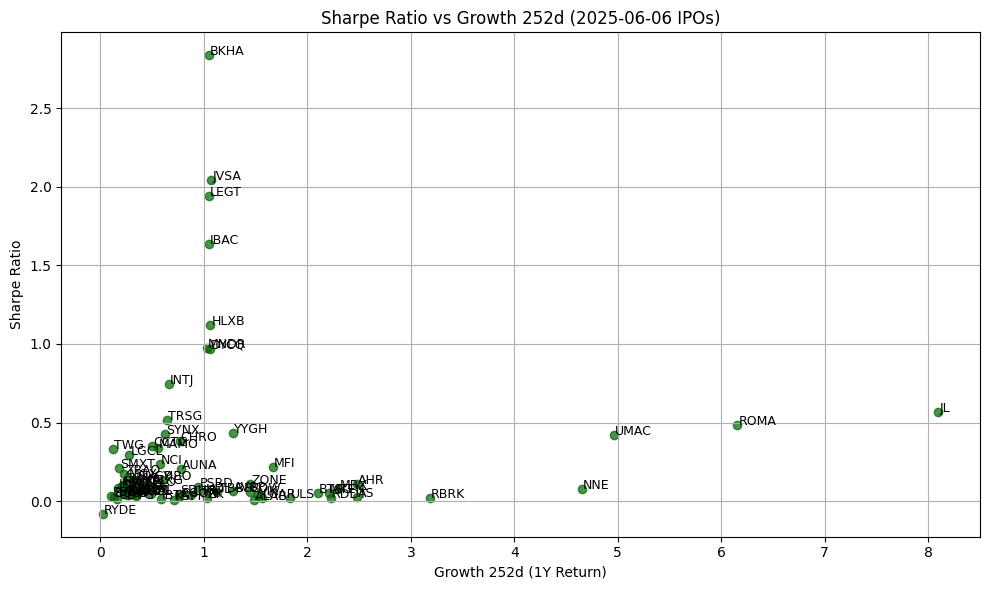

In [55]:
import matplotlib.pyplot as plt

# Asegúrate de tener las columnas necesarias y eliminar valores nulos
plot_df = stocks_filtrados[["Ticker", "growth_252d", "Sharpe"]].dropna()

# Crear gráfico de dispersión
plt.figure(figsize=(10, 6))
plt.scatter(plot_df["growth_252d"], plot_df["Sharpe"], c="darkgreen", alpha=0.7)

# Agregar etiquetas con los tickers
for i, row in plot_df.iterrows():
    plt.text(row["growth_252d"] + 0.01, row["Sharpe"], row["Ticker"], fontsize=9)

# Etiquetas y formato
plt.xlabel("Growth 252d (1Y Return)")
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe Ratio vs Growth 252d (2025-06-06 IPOs)")
plt.grid(True)
plt.tight_layout()
plt.show()


# Question 3: [IPO] ‘Fixed Months Holding Strategy’

In [56]:
stocks_df_copy = stocks_df

In [57]:
stocks_df.head().T

,0,1,2,3,4
Open,23.0,24.26,25.85,26.440001,27.209999
High,24.27,26.15,26.879999,26.49,27.209999
Low,22.139999,23.98,25.075001,25.500999,25.5
Close,23.799999,25.700001,26.48,26.290001,26.139999
Volume,3335800,990500,555100,302700,200900
Dividends,0.0,0.0,0.0,0.0,0.0
Stock Splits,0.0,0.0,0.0,0.0,0.0
Ticker,BOW,BOW,BOW,BOW,BOW
Year,2024,2024,2024,2024,2024
Month,5,5,5,5,5


In [58]:
stocks_df.shape

(23396, 27)

In [59]:
stocks_df_copy.describe().T

,count,mean,min,25%,50%,75%,max,std
Open,23396.0,15.57442,0.0004,1.9,7.0475,18.6,228.800003,23.589713
High,23396.0,16.007429,0.0005,2.0,7.445,19.156974,230.410004,24.189774
Low,23396.0,15.150077,0.0003,1.8,6.75,18.0,221.5,22.995321
Close,23396.0,15.562622,0.0004,1.89,7.024,18.6,225.229996,23.595786
Volume,23396.0,912598.201616,0.0,22600.0,120700.0,482375.0,566927900.0,6512828.593038
Dividends,23396.0,0.000516,0.0,0.0,0.0,0.0,1.915,0.02529
Stock Splits,23396.0,0.000018,0.0,0.0,0.0,0.0,0.2,0.001675
Year,23396.0,2024.375064,2024.0,2024.0,2024.0,2025.0,2025.0,0.48415
Month,23396.0,6.116943,1.0,4.0,6.0,9.0,12.0,3.24741
Weekday,23396.0,2.012652,0.0,1.0,2.0,3.0,4.0,1.412796


In [60]:
stocks_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Open,23396.0,15.57442,0.0004,1.9,7.0475,18.6,228.800003,23.589713
High,23396.0,16.007429,0.0005,2.0,7.445,19.156974,230.410004,24.189774
Low,23396.0,15.150077,0.0003,1.8,6.75,18.0,221.5,22.995321
Close,23396.0,15.562622,0.0004,1.89,7.024,18.6,225.229996,23.595786
Volume,23396.0,912598.201616,0.0,22600.0,120700.0,482375.0,566927900.0,6512828.593038
Dividends,23396.0,0.000516,0.0,0.0,0.0,0.0,1.915,0.02529
Stock Splits,23396.0,0.000018,0.0,0.0,0.0,0.0,0.2,0.001675
Year,23396.0,2024.375064,2024.0,2024.0,2024.0,2025.0,2025.0,0.48415
Month,23396.0,6.116943,1.0,4.0,6.0,9.0,12.0,3.24741
Weekday,23396.0,2.012652,0.0,1.0,2.0,3.0,4.0,1.412796


In [61]:
stocks_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_252d,growth_365d,growth_future_30d,SMA10,SMA20,growing_moving_average,high_minus_low_relative,volatility,is_positive_growth_30d_future,Sharpe
0,23.000000,24.270000,22.139999,23.799999,3335800,0.0,0.0,BOW,2024,5,...,NaN,NaN,1.092017,NaN,NaN,0,0.089496,NaN,1,NaN
1,24.260000,26.150000,23.980000,25.700001,990500,0.0,0.0,BOW,2024,5,...,NaN,NaN,0.998054,NaN,NaN,0,0.084436,NaN,0,NaN
2,25.850000,26.879999,25.075001,26.480000,555100,0.0,0.0,BOW,2024,5,...,NaN,NaN,1.001133,NaN,NaN,0,0.068165,NaN,1,NaN
3,26.440001,26.490000,25.500999,26.290001,302700,0.0,0.0,BOW,2024,5,...,NaN,NaN,0.987828,NaN,NaN,0,0.037619,NaN,0,NaN
4,27.209999,27.209999,25.500000,26.139999,200900,0.0,0.0,BOW,2024,5,...,NaN,NaN,1.037490,NaN,NaN,0,0.065417,NaN,1,NaN


In [62]:
stocks_df.Ticker.nunique()

75

In [63]:
for i in range(1,13):
    stocks_df[f'growth_future_{i}m'] = stocks_df['Close'].shift(-i * 21) / stocks_df['Close']


In [64]:
stocks_df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_future_3m,growth_future_4m,growth_future_5m,growth_future_6m,growth_future_7m,growth_future_8m,growth_future_9m,growth_future_10m,growth_future_11m,growth_future_12m
0,23.000000,24.270000,22.139999,23.799999,3335800,0.0,0.0,BOW,2024,5,...,1.301681,1.167647,1.239076,1.461765,1.443698,1.357983,1.389076,1.722689,1.698319,1.533613
1,24.260000,26.150000,23.980000,25.700001,990500,0.0,0.0,BOW,2024,5,...,1.196498,1.090661,1.148249,1.392996,1.354086,1.280934,1.276654,1.640078,1.589883,1.445914
2,25.850000,26.879999,25.075001,26.480000,555100,0.0,0.0,BOW,2024,5,...,1.155589,1.048338,1.111027,1.361783,1.327039,1.233761,1.270015,1.535121,1.517749,1.408610
3,26.440001,26.490000,25.500999,26.290001,302700,0.0,0.0,BOW,2024,5,...,1.149106,1.053252,1.139977,1.378851,1.311525,1.248764,1.315709,1.559528,1.521491,1.430582
4,27.209999,27.209999,25.500000,26.139999,200900,0.0,0.0,BOW,2024,5,...,1.198164,1.071538,1.149579,1.383321,1.321729,1.236802,1.303367,1.595639,1.584545,1.432670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23391,2.840000,3.000000,2.640000,2.875000,63100,0.0,0.0,ROMA,2025,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23392,2.850000,2.935000,2.790000,2.795000,10200,0.0,0.0,ROMA,2025,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23393,2.883000,2.900000,2.730000,2.790000,33600,0.0,0.0,ROMA,2025,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23394,2.960000,3.120000,2.700000,2.780000,123300,0.0,0.0,ROMA,2025,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
min_date = stocks_df.groupby('Ticker')['Date'].min().reset_index()

In [66]:
min_date

,Ticker,Date
0,AHR,2024-02-07
1,ALAB,2024-03-20
2,ANRO,2024-02-02
3,AS,2024-02-01
4,AUNA,2024-03-22
...,...,...
70,YIBO,2024-01-25
71,YYGH,2024-04-22
72,ZBAO,2024-04-02
73,ZK,2024-05-10


In [67]:
df_joined = min_date.merge(stocks_df, how='inner', left_on=['Ticker', 'Date'], right_on=['Ticker', 'Date'])


In [68]:
df_joined.shape

(75, 39)

In [69]:
df_joined.describe().T.tail(12).sort_values(by='mean',ascending=False)

,count,mean,min,25%,50%,75%,max,std
growth_future_12m,75.0,12.631945,0.038947,0.230832,0.752083,1.34801,878.017289,101.280406
growth_future_11m,75.0,12.583411,0.023674,0.266821,0.719512,1.221407,878.448251,101.336187
growth_future_10m,75.0,12.560879,0.037769,0.245455,0.777871,1.244715,874.137972,100.834827
growth_future_2m,75.0,0.940544,0.0738,0.685815,1.0,1.154013,4.874759,0.574545
growth_future_1m,75.0,0.927259,0.098947,0.778984,0.977,1.046509,2.646505,0.346261
growth_future_9m,75.0,0.881779,0.033144,0.22674,0.822715,1.049719,6.764933,0.936957
growth_future_6m,75.0,0.864185,0.061432,0.38456,0.802239,1.093948,3.67052,0.653179
growth_future_7m,75.0,0.847149,0.044086,0.29687,0.844875,1.114468,5.12235,0.712943
growth_future_3m,75.0,0.833824,0.060947,0.511212,0.9275,1.069085,2.04,0.409763
growth_future_8m,75.0,0.832983,0.043103,0.208677,0.812109,1.082433,5.171484,0.762423


In [70]:
cols = [f'growth_future_{i}m' for i in range(1, 13)]
outlier_candidates = df_joined[cols].idxmax()
df_joined.loc[outlier_candidates]


,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Year,...,growth_future_3m,growth_future_4m,growth_future_5m,growth_future_6m,growth_future_7m,growth_future_8m,growth_future_9m,growth_future_10m,growth_future_11m,growth_future_12m
29,JL,2024-01-24,7.5000,10.8200,6.1400,7.4400,1361900,0.0,0.0,2024,...,0.129032,0.083333,0.063306,0.064516,0.044086,0.050806,0.055242,0.037769,0.408602,0.602151
45,NNE,2024-05-08,3.6000,6.2700,3.5100,5.1900,5722800,0.0,0.0,2024,...,1.562620,1.425819,3.213873,3.670520,5.122350,5.171484,6.764933,5.352601,4.383430,4.849711
55,RYDE,2024-03-06,3.7000,5.0000,3.5500,4.0000,2689400,0.0,0.0,2024,...,2.040000,1.605000,1.717500,3.035000,0.185000,0.120000,0.099750,0.121250,0.091000,0.079000
55,RYDE,2024-03-06,3.7000,5.0000,3.5500,4.0000,2689400,0.0,0.0,2024,...,2.040000,1.605000,1.717500,3.035000,0.185000,0.120000,0.099750,0.121250,0.091000,0.079000
45,NNE,2024-05-08,3.6000,6.2700,3.5100,5.1900,5722800,0.0,0.0,2024,...,1.562620,1.425819,3.213873,3.670520,5.122350,5.171484,6.764933,5.352601,4.383430,4.849711
45,NNE,2024-05-08,3.6000,6.2700,3.5100,5.1900,5722800,0.0,0.0,2024,...,1.562620,1.425819,3.213873,3.670520,5.122350,5.171484,6.764933,5.352601,4.383430,4.849711
45,NNE,2024-05-08,3.6000,6.2700,3.5100,5.1900,5722800,0.0,0.0,2024,...,1.562620,1.425819,3.213873,3.670520,5.122350,5.171484,6.764933,5.352601,4.383430,4.849711
45,NNE,2024-05-08,3.6000,6.2700,3.5100,5.1900,5722800,0.0,0.0,2024,...,1.562620,1.425819,3.213873,3.670520,5.122350,5.171484,6.764933,5.352601,4.383430,4.849711
45,NNE,2024-05-08,3.6000,6.2700,3.5100,5.1900,5722800,0.0,0.0,2024,...,1.562620,1.425819,3.213873,3.670520,5.122350,5.171484,6.764933,5.352601,4.383430,4.849711
68,VHAI,2024-09-11,0.0107,0.0157,0.0062,0.0116,37503977,0.0,0.0,2024,...,0.431034,0.422414,0.310345,0.161207,0.103448,0.043103,0.051724,874.137972,878.448251,878.017289


In [71]:
df_clean = df_joined[df_joined['Ticker'] != 'VHAI']

In [72]:
df_clean.describe().T.tail(12).sort_values(by='mean',ascending=False)

,count,mean,min,25%,50%,75%,max,std
growth_future_2m,74.0,0.946556,0.0738,0.696703,1.0,1.161482,4.874759,0.576087
growth_future_12m,74.0,0.937548,0.038947,0.230342,0.731365,1.231121,4.849711,0.901825
growth_future_1m,74.0,0.933965,0.098947,0.785894,0.98225,1.047153,2.646505,0.343686
growth_future_10m,74.0,0.917945,0.037769,0.242424,0.772592,1.200791,5.352601,0.911431
growth_future_9m,74.0,0.892996,0.033144,0.244048,0.833357,1.055767,6.764933,0.938269
growth_future_11m,74.0,0.882534,0.023674,0.264661,0.717585,1.106769,4.445545,0.863183
growth_future_6m,74.0,0.873685,0.061432,0.408536,0.814453,1.098922,3.67052,0.652401
growth_future_7m,74.0,0.857199,0.044086,0.327393,0.848113,1.132689,5.12235,0.712441
growth_future_8m,74.0,0.843658,0.050746,0.234632,0.828492,1.08628,5.171484,0.761964
growth_future_3m,74.0,0.839268,0.060947,0.515089,0.932804,1.07238,2.04,0.409821


# Question 4: [Strategy] Simple RSI-Based Trading Strategy

In [74]:
import gdown
import pandas as pd

file_id = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.parquet", quiet=False)
df = pd.read_parquet("data.parquet", engine="pyarrow")


Downloading...
From (original): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-
From (redirected): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-&confirm=t&uuid=b43b44a8-7080-4736-bb90-ea9757a5b6df
To: /home/maxkaizo/stock-markets-analytics-zoomcamp/02-dataframe-analysis/data.parquet
100%|██████████| 130M/130M [01:45<00:00, 1.23MB/s] 


In [75]:
rsi_threshold = 25
selected_df = df[
    (df['rsi'] < rsi_threshold) &
    (df['Date'] >= '2000-01-01') &
    (df['Date'] <= '2025-06-01')
]

In [76]:
selected_df

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_brent_oil_7d,growth_brent_oil_30d,growth_brent_oil_90d,growth_brent_oil_365d,growth_btc_usd_1d,growth_btc_usd_3d,growth_btc_usd_7d,growth_btc_usd_30d,growth_btc_usd_90d,growth_btc_usd_365d
3668,20.056772,20.114241,19.405453,19.673643,99915200.0,0.0,0.0,MSFT,2000,2000-09-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3669,19.692798,19.807736,19.060636,19.309669,69037800.0,0.0,0.0,MSFT,2000,2000-09-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3680,18.256067,18.332693,17.317403,17.336559,85374000.0,0.0,0.0,MSFT,2000,2000-10-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3681,17.279087,17.336557,16.704395,16.991741,136453400.0,0.0,0.0,MSFT,2000,2000-10-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3682,17.010902,17.547282,16.934277,16.972589,81099400.0,0.0,0.0,MSFT,2000,2000-10-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,797.393417,806.609179,764.362578,769.289795,7251950.0,0.0,0.0,LT.NS,2020,2020-03-01,...,0.764911,0.515014,0.457056,0.336604,1.181878,1.234663,1.245515,0.610451,0.857647,1.514674
4406,774.673304,800.951963,758.522860,788.998840,6130185.0,0.0,0.0,LT.NS,2020,2020-03-01,...,0.753842,0.491171,0.431611,0.320580,1.001225,1.186226,1.114145,0.643468,0.862000,1.538415
4407,738.175133,739.041975,644.192390,660.662170,7308612.0,0.0,0.0,LT.NS,2020,2020-03-01,...,0.813666,0.496236,0.434706,0.322131,1.100520,1.035093,1.279557,0.663996,0.876243,1.595238
4408,698.550405,699.244329,621.756122,654.971985,7110384.0,10.0,0.0,LT.NS,2020,2020-03-01,...,0.802068,0.509668,0.437480,0.319412,1.049637,1.088881,1.288802,0.678603,0.925726,1.699390


In [77]:
net_income = 1000 * (selected_df['growth_future_30d'] - 1).sum()

In [78]:
net_income

np.float64(24295.523125248386)